In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.ticker import FuncFormatter

In [3]:
df = pd.read_excel(r"C:\Users\gopal\OneDrive\Desktop\Healthcare analysis\dataset\Cleaned_Hospital_Management_Records.xlsx")
df

,PatientID,PatientName,Age,Gender,PhoneNumber,Email,Address,City,State,RegistrationDate,...,AmountPaid,PendingAmount,PaymentMode,BillingDate,InsuranceProvider,FeedbackRating,Disease,AgeGroup,HospitalStays,PaymentStatus
0,45d3d0ef-38c3-49c9-a0bd-c68d9ee90a0f,Drishya Mammen,25,Female,2416034981,atank@arora-master.net,"40/720, Chakrabarti Circle, Bhilwara-385220",Tadipatri,Bihar,2024-10-03,...,59341.66,20837.50,Card,2025-03-13,Borah Inc,5,Flu,YoungAdult,126,Pending
1,afd50add-bab4-4e63-baca-3d92585821da,Rania Balay,44,Male,912947000000,kaladhruv@ratti.com,"66, Master Nagar, Mumbai-334047",Allahabad,Goa,2024-03-04,...,17818.53,153809.78,Insurance,2025-06-03,Unknown,2,Flu,Adult,67,Pending
2,d59f02b8-36be-4450-858f-22940e4d0a9b,Rhea Bhat,44,Other,1714094485,abhalla@batra.com,"013, Jayaraman Chowk, Tiruchirappalli-908041",Asansol,Chhattisgarh,2025-02-08,...,97493.48,86936.05,UPI,2025-04-05,Unknown,1,Cancer,Adult,39,Pending
3,d55dfe6a-0da2-4352-8321-15dda501a571,Elakshi Chatterjee,38,Other,910622000000,piyachacko@gmail.com,"H.No. 798, Das Nagar, Ahmednagar 130849",Kulti,Goa,2024-07-25,...,7275.76,31819.34,UPI,2025-02-24,Khalsa-Bala,4,COVID-19,Adult,93,Pending
4,1ce3dd94-318a-494d-8e91-e070237fe54f,Ayesha Toor,75,Female,5104023087,jivika45@hotmail.com,"H.No. 487, Koshy Ganj, Katihar 463550",Ramgarh,Tripura,2024-02-28,...,10372.96,7506.35,UPI,2025-04-20,Unknown,1,Hypertension,Elder,129,Pending
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,f3274e46-f1e9-4f1d-90e7-4a1f2e851088,Yasmin Kashyap,8,Other,8500267260,rbhandari@sachar-madan.com,"920, Sura Road, Thiruvananthapuram 767371",Guntur,Uttar Pradesh,2023-12-03,...,69308.77,89023.79,Insurance,2025-05-13,Unknown,5,Migraine,Child,344,Pending
9996,78d3a39a-3813-43cd-9415-c5214b6608d3,Eva Kumer,36,Other,915206000000,eshani15@yahoo.com,"56/345, Agarwal Nagar, Gandhinagar 446646",Kolhapur,Tamil Nadu,2024-11-08,...,26961.14,121367.98,UPI,2025-04-16,Raval-Halder,3,Cancer,Adult,22,Pending
9997,2c7c5224-b94d-4ba5-984b-bcbf74a9790d,Advik Korpal,16,Male,1777904014,surelakshi@hotmail.com,"H.No. 881, Konda, Kolhapur 490469",Mumbai,Haryana,2025-02-03,...,14904.67,59032.21,Cash,2025-05-08,Unknown,1,Diabetes,Child,68,Pending
9998,871dbc36-6a4d-43c2-8612-db28748a04c9,Keya Bera,77,Other,3759349906,barmanjhanvi@bedi.com,"H.No. 89, Samra Street, Hospet 521453",Unnao,Jharkhand,2023-08-02,...,42274.80,147564.18,UPI,2024-05-08,Unknown,4,Hypertension,Elder,257,Pending


Monthly Patient Trend

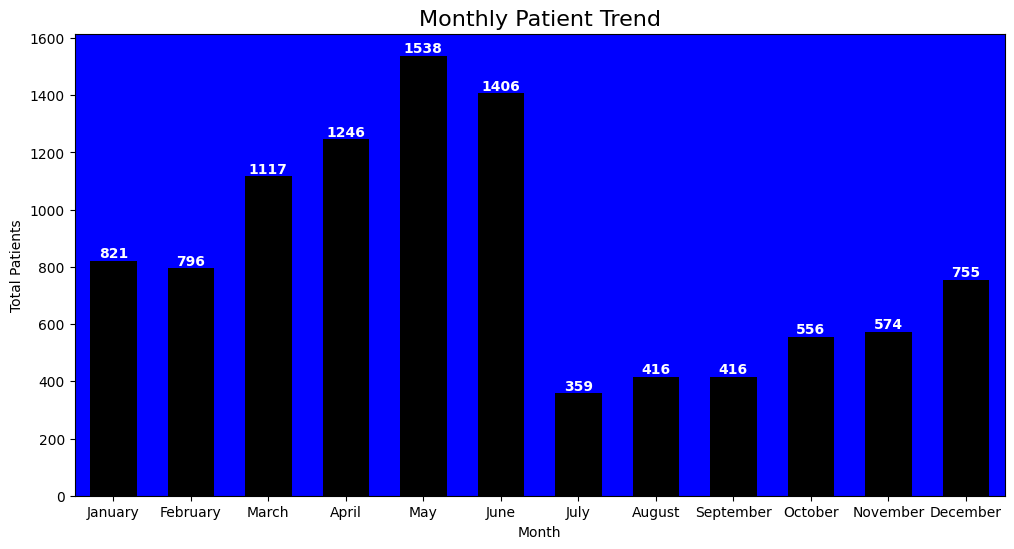

In [4]:
Monthly_Patient_Trend = df.groupby(df['AdmissionDate'].dt.month)["PatientID"].count().reset_index(name='Total_Patients')
month_order = ["January", "February", "March", "April", "May", "June", "July", "August", "September", "October", "November", "December"]
Monthly_Patient_Trend["Months"] = month_order
plt.figure(figsize=(12, 6))
ax = sns.barplot(data=Monthly_Patient_Trend, x="Months", y="Total_Patients", color="black", width=0.6)
ax.set_facecolor(color="blue")
ax.bar_label(ax.containers[0], fmt="%.0f", color="white", fontweight="bold")
plt.title('Monthly Patient Trend', fontsize=16)
plt.xlabel('Month')
plt.ylabel('Total Patients')
plt.show()

Monthly Revenue Trend

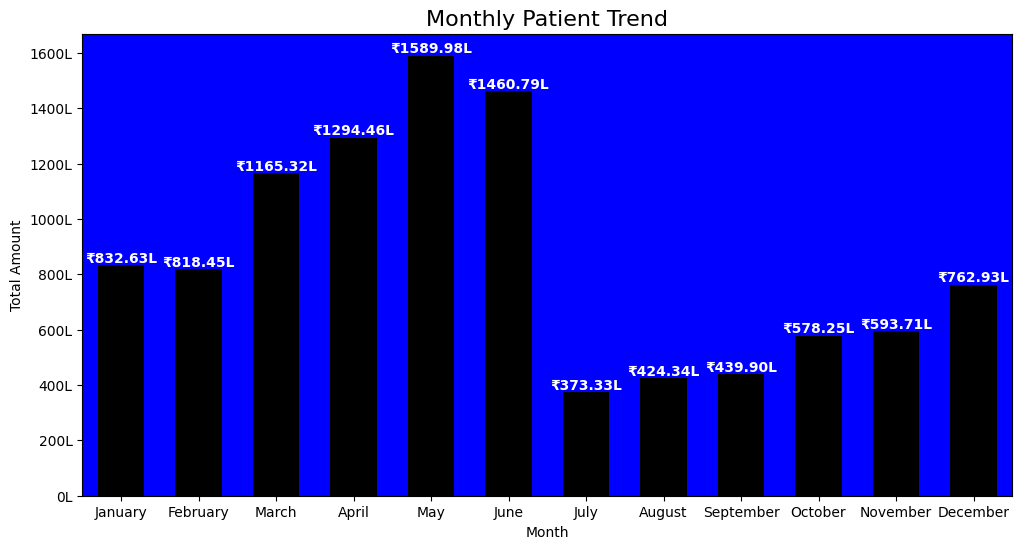

In [5]:
Monthly_Revenue_Trend = df.groupby(df['AdmissionDate'].dt.month)["TotalBillAmount"].sum().reset_index(name='Total_Amount')
month_order = ["January", "February", "March", "April", "May", "June", "July", "August", "September", "October", "November", "December"]
Monthly_Revenue_Trend["Months"] = month_order
plt.figure(figsize=(12, 6))
ax = sns.barplot(data=Monthly_Revenue_Trend, x="Months", y="Total_Amount", color="black", width=0.6)
ax.set_facecolor(color="blue")
#ax.bar_label(ax.containers[0], fmt="%.0f", color="white", fontweight="bold")
for container in ax.containers :
    labels = [f"₹{v/100000:.2f}L"
              for v in container.datavalues]
    ax.bar_label(container, labels=labels, color="white", fontweight="bold")
ax.yaxis.set_major_formatter(FuncFormatter(lambda x, pos:f"{x/100000:.0f}L"))
plt.title('Monthly Patient Trend', fontsize=16)
plt.xlabel('Month')
plt.ylabel('Total Amount')
plt.show()

Disease Distribution 

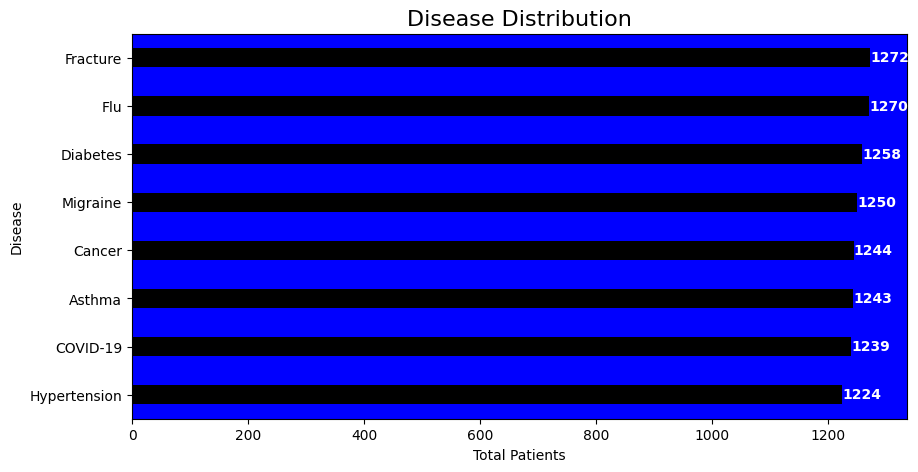

In [6]:
disease = df["Disease"].value_counts().reset_index(name="Total Patient")
#disease.columns = ["Disease", "Total Patient"]
plt.figure(figsize=(10,5))
ax = sns.barplot(data=disease, y="Disease", x="Total Patient", color="black", width=0.4)
ax.set_facecolor(color="blue")
ax.bar_label(ax.containers[0],fmt="%.0f", color="white", fontweight="bold")
plt.title('Disease Distribution', fontsize=16)
plt.xlabel('Total Patients')
plt.ylabel('Disease')
plt.show()  
    

Department Revenue

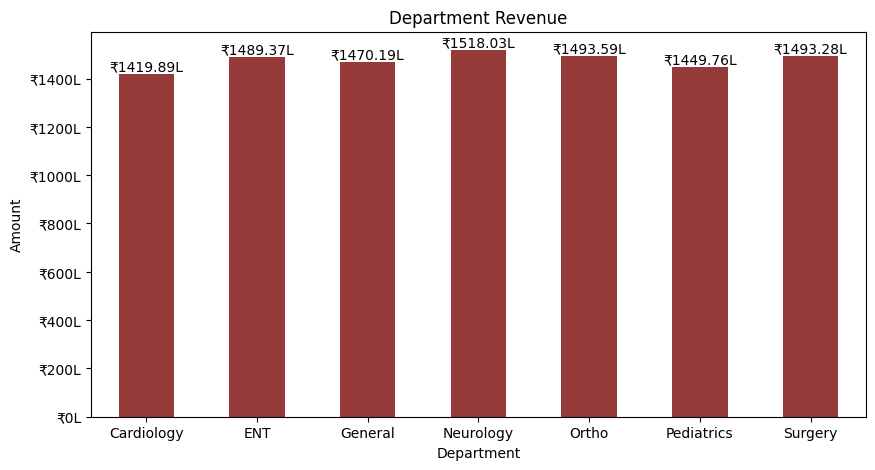

In [7]:
Department_Revenue = df.groupby("Department")["TotalBillAmount"].sum().reset_index(name="Total Amount")
plt.figure(figsize=(10, 5))
ax = sns.barplot(data=Department_Revenue, x="Department", y="Total Amount", color="brown", width=0.5)
for container in ax.containers:
    label = [f"₹{v/100000:.2f}L"
             for v in container.datavalues]
    ax.bar_label(container, labels=label)
ax.yaxis.set_major_formatter(FuncFormatter(lambda x, pos : f"₹{x/100000:.0f}L"))
plt.title("Department Revenue")
plt.xlabel("Department")
plt.ylabel("Amount")
plt.show ()   

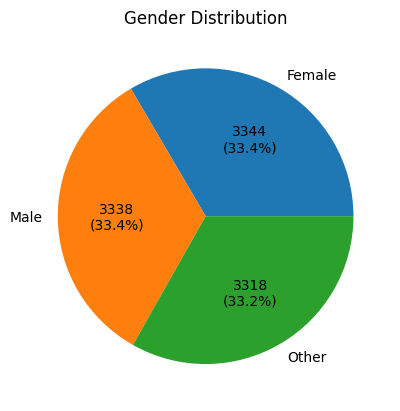

In [8]:
gender = df["Gender"].value_counts()
gender.plot(kind="pie", autopct=lambda pct:f"{int(round(pct/100*gender.sum()))}\n({pct:.1f}%)")
plt.title("Gender Distribution")
plt.ylabel("")
plt.show()

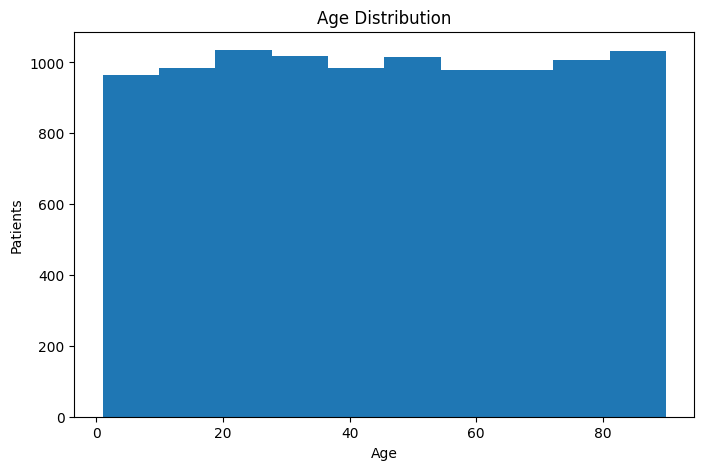

In [9]:
plt.figure(figsize=(8,5))
plt.hist(df["Age"], bins=10)
plt.title("Age Distribution")
plt.xlabel("Age")
plt.ylabel("Patients")
plt.show()


Revenue by Payment Mode

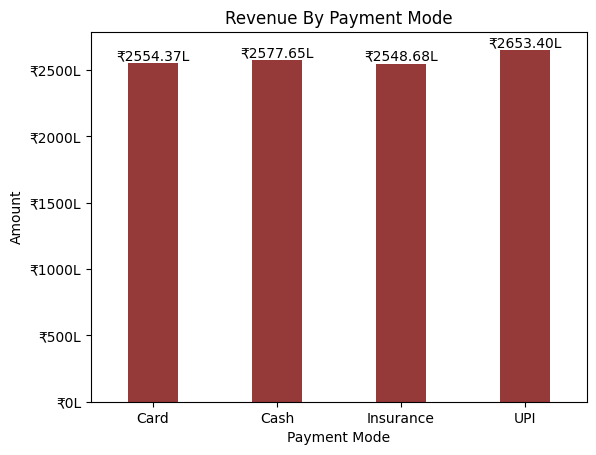

In [10]:
Payment = df.groupby("PaymentMode")["TotalBillAmount"].sum().reset_index(name="Total Revenue")
ax = sns.barplot(data=Payment, x="PaymentMode", y="Total Revenue", color="brown", width=0.4)
for container in ax.containers:
    label = [f"₹{v/100000:.2f}L"
             for v in container.datavalues]
    ax.bar_label(container, labels=label, color="black")
ax.yaxis.set_major_formatter(FuncFormatter(lambda x, pos: f"₹{x/100000:.0f}L"))
plt.title("Revenue By Payment Mode")
plt.ylabel("Amount")
plt.xlabel("Payment Mode")
plt.show()    

Disease by Gender

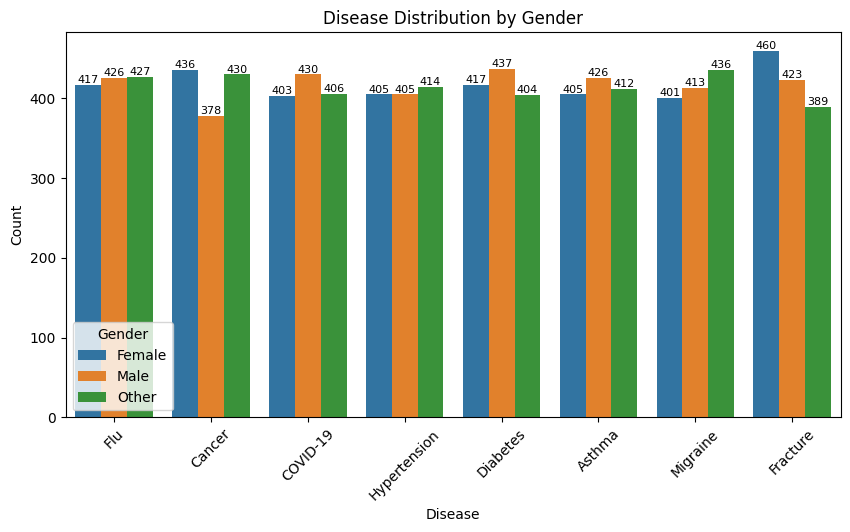

In [16]:
plt.figure(figsize=(10, 5))
ax = sns.countplot(data=df, x="Disease", hue="Gender")
for container in ax.containers:
    ax.bar_label(container, fontsize=8, color="black")
plt.title("Disease Distribution by Gender")
plt.xlabel("Disease")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.show()

Average hospital stay by Disease

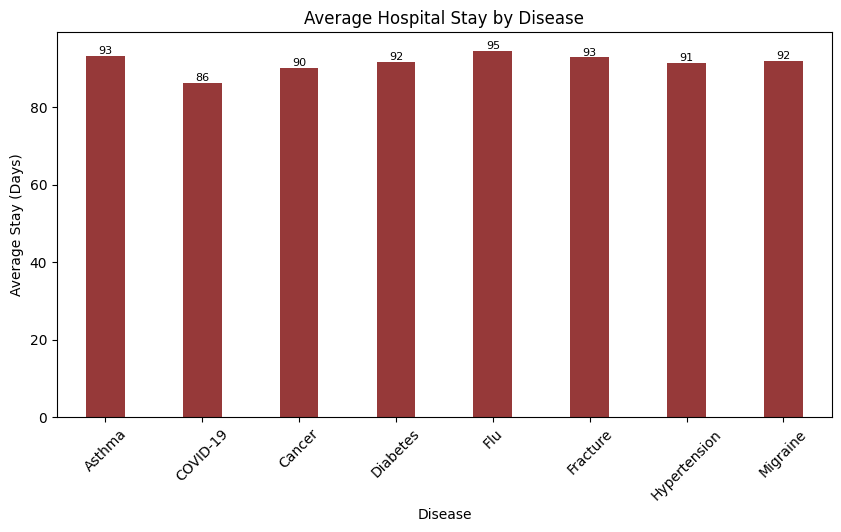

In [19]:
avg_hospital_stay = df.groupby("Disease")["HospitalStays"].mean().reset_index(name="Average Stay")
plt.figure(figsize=(10, 5))
ax = sns.barplot(data=avg_hospital_stay, x="Disease", y="Average Stay", color="brown", width=0.4)
for container in ax.containers:
    ax.bar_label(container,fmt="%.0f", fontsize=8, color="black")  
plt.title("Average Hospital Stay by Disease")
plt.xlabel("Disease")       
plt.ylabel("Average Stay (Days)")
plt.xticks(rotation=45)     
plt.show()    

RoomType Total Patient

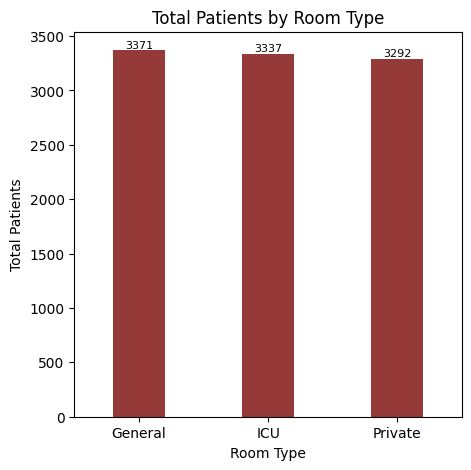

In [25]:
Roomtype_Patient = df.groupby("RoomType")["PatientID"].count().reset_index(name="Total Patients")
plt.figure(figsize=(5, 5))
ax = sns.barplot(data=Roomtype_Patient, x="RoomType", y="Total Patients", color="brown", width=0.4)
for container in ax.containers:
    ax.bar_label(container,fmt="%.0f", fontsize=8, color="black")       
plt.title("Total Patients by Room Type")
plt.xlabel("Room Type") 
plt.ylabel("Total Patients")
plt.show()    

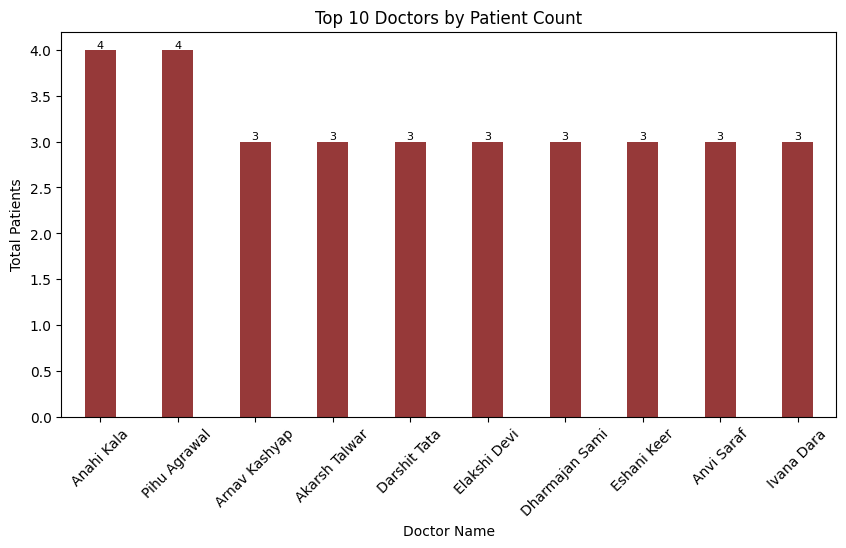

In [26]:
top_doctors = df.groupby("DoctorName")["PatientID"].count().reset_index(name="Total Patients").sort_values(by="Total Patients", ascending=False).head(10)
plt.figure(figsize=(10, 5))
ax = sns.barplot(data=top_doctors, x="DoctorName", y="Total Patients", color="brown", width=0.4)
for container in ax.containers:
    ax.bar_label(container,fmt="%.0f", fontsize=8, color="black")       
plt.title("Top 10 Doctors by Patient Count")
plt.xlabel("Doctor Name") 
plt.ylabel("Total Patients")
plt.xticks(rotation=45)
plt.show()    

Total Patients by Reson of Admission

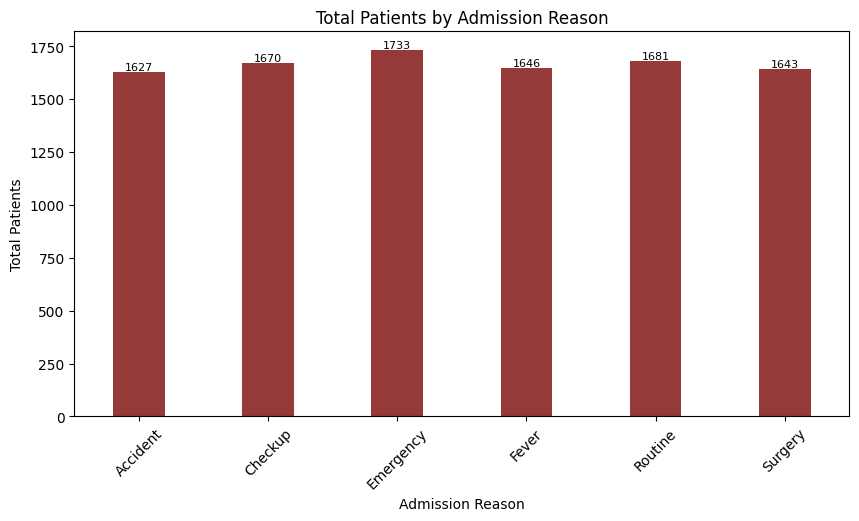

In [27]:
patient_admissions = df.groupby("AdmissionReason")["PatientID"].count().reset_index(name='Total_Patients')
plt.figure(figsize=(10, 5))
ax = sns.barplot(data=patient_admissions, x="AdmissionReason", y="Total_Patients", color="brown", width=0.4)                                            
for container in ax.containers:     
    ax.bar_label(container,fmt="%.0f", fontsize=8, color="black")       
plt.title("Total Patients by Admission Reason")
plt.xlabel("Admission Reason") 
plt.ylabel("Total Patients")
plt.xticks(rotation=45)
plt.show()    